# 1. IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")

# 2. DATA LOADING

In [2]:
df = pd.read_csv(
    "Data/Raw_Responses/raw_google_form_export.csv",
    skiprows=[1],
    encoding="latin-1" 
)
df.head()

,Timestamp,1. Age\nExample: 23 [Restricted to 19ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,2. Gender\nExample: Male,3. Study_Hours (per day) \nExample: 3,4. Class_Attendance (%) \nExample: 85,5. Tuition (Private Coaching) \nExample: Yes,6. Exam_Frequency (per semester) \nExample: 4,7. Assignment_Load (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,8. Sleep_Hours (per day) \nExample: 6,9. Physical_Exercise (hours per week) \nExample: 2,10. Social_Media_Use (hours per day) \nExample: 3,11. Screen_Time (hours per day) \nExample: 6,12. Family_Income_Level \nExample: Middle,13. Peer_Pressure (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,14. Family_Support (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,15. Anxiety_Level (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,16. University_Type \nExample: Public University,17. Stress_Score (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï,18. Stress_Level \nExample: Moderate
0,2025/10/01 12:36:28 AM GMT+6,24,Female,8,43,Yes,6,8,5,Yes,6,8,Medium,3,7,8,National University,22,High
1,2025/10/01 01:12:57 AM GMT+6,21,Female,4,56,Yes,3,6,5,Yes,7,9,Low,2,5,3,Private University,16,Medium
2,2025/10/01 01:49:26 AM GMT+6,23,Female,4,46,No,8,6,8,No,5,6,Medium,8,6,5,Private University,16,Medium
3,2025/10/01 02:25:55 AM GMT+6,20,Male,8,46,No,5,1,6,Yes,0,7,Medium,5,6,2,National University,1,Low
4,2025/10/01 03:02:23 AM GMT+6,19,Male,2,95,No,5,2,7,No,3,6,Low,2,6,1,National University,4,Low


In [3]:
# Rename kolom setelah load — supaya bisa dipakai dari Section 3
df.columns = [
    "Timestamp","Age","Gender","Study_Hours","Class_Attendance",
    "Tuition","Exam_Frequency","Assignment_Load",
    "Sleep_Hours","Physical_Exercise","Social_Media_Use",
    "Screen_Time","Family_Income_Level","Peer_Pressure",
    "Family_Support","Anxiety_Level","University_Type",
    "Stress_Score","Stress_Level"
]

# 3. DATA UNDERSTANDING

In [4]:
print("Shape:", df.shape)
print("\nMissing:\n", df.isnull().sum())
print("\nNegative:\n", (df.select_dtypes(include="number") < 0).sum())
print("\nDuplicate:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)

Shape: (2999, 19)

Missing:
 Timestamp              0
Age                    0
Gender                 0
Study_Hours            0
Class_Attendance       0
Tuition                0
Exam_Frequency         0
Assignment_Load        0
Sleep_Hours            0
Physical_Exercise      0
Social_Media_Use       0
Screen_Time            0
Family_Income_Level    0
Peer_Pressure          0
Family_Support         0
Anxiety_Level          0
University_Type        0
Stress_Score           0
Stress_Level           0
dtype: int64

Negative:
 Age                   0
Study_Hours           0
Class_Attendance      0
Exam_Frequency        0
Assignment_Load       0
Sleep_Hours           0
Social_Media_Use      0
Screen_Time           0
Peer_Pressure         0
Family_Support        0
Anxiety_Level         0
Stress_Score        110
dtype: int64

Duplicate: 0

Dtypes:
 Timestamp              object
Age                     int64
Gender                 object
Study_Hours             int64
Class_Attendance        in

In [5]:
print(df.info())
print(df.describe())
print("Duplicate:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Timestamp            2999 non-null   object
 1   Age                  2999 non-null   int64 
 2   Gender               2999 non-null   object
 3   Study_Hours          2999 non-null   int64 
 4   Class_Attendance     2999 non-null   int64 
 5   Tuition              2999 non-null   object
 6   Exam_Frequency       2999 non-null   int64 
 7   Assignment_Load      2999 non-null   int64 
 8   Sleep_Hours          2999 non-null   int64 
 9   Physical_Exercise    2999 non-null   object
 10  Social_Media_Use     2999 non-null   int64 
 11  Screen_Time          2999 non-null   int64 
 12  Family_Income_Level  2999 non-null   object
 13  Peer_Pressure        2999 non-null   int64 
 14  Family_Support       2999 non-null   int64 
 15  Anxiety_Level        2999 non-null   int64 
 16  Univer

In [6]:
print(df.columns.tolist())

['Timestamp', 'Age', 'Gender', 'Study_Hours', 'Class_Attendance', 'Tuition', 'Exam_Frequency', 'Assignment_Load', 'Sleep_Hours', 'Physical_Exercise', 'Social_Media_Use', 'Screen_Time', 'Family_Income_Level', 'Peer_Pressure', 'Family_Support', 'Anxiety_Level', 'University_Type', 'Stress_Score', 'Stress_Level']


In [7]:
#DISTRIBUSI TARGET
df["Stress_Level"].value_counts()

Stress_Level
Medium    1430
Low       1243
High       326
Name: count, dtype: int64

In [8]:
df["Stress_Level"].value_counts(normalize=True) * 100

Stress_Level
Medium    47.682561
Low       41.447149
High      10.870290
Name: proportion, dtype: float64

In [9]:
#CEK CATEGORICAL DISTRIBUTION
for col in ["Gender", "University_Type", "Family_Income_Level", "Tuition"]:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Female    1538
Male      1461
Name: count, dtype: int64

University_Type
University_Type
Public University      1003
National University     999
Private University      997
Name: count, dtype: int64

Family_Income_Level
Family_Income_Level
Medium    1333
Low       1058
High       608
Name: count, dtype: int64

Tuition
Tuition
No     1544
Yes    1455
Name: count, dtype: int64


In [10]:
#CEK KORELASI
df.corr(numeric_only=True)["Screen_Time"].sort_values(ascending=False)

Screen_Time         1.000000
Stress_Score        0.494516
Class_Attendance    0.029559
Sleep_Hours         0.018414
Anxiety_Level       0.018224
Exam_Frequency      0.014956
Social_Media_Use    0.014897
Assignment_Load     0.004322
Age                -0.012583
Peer_Pressure      -0.026959
Family_Support     -0.034991
Study_Hours        -0.035367
Name: Screen_Time, dtype: float64

In [11]:
#GROUP ANALYSIS
df.groupby("Stress_Level")[[
    "Sleep_Hours",
    "Screen_Time",
    "Study_Hours",
    "Peer_Pressure"
]].mean().round(2)

,Sleep_Hours,Screen_Time,Study_Hours,Peer_Pressure
Stress_Level,,,,
High,5.88,8.65,4.29,4.83
Low,6.90,4.37,4.51,5.00
Medium,6.34,6.64,4.51,5.01


# 4. DATA CLEANING

In [12]:
df.columns = [
    "Timestamp","Age","Gender","Study_Hours","Class_Attendance",
    "Tuition","Exam_Frequency","Assignment_Load",
    "Sleep_Hours","Physical_Exercise","Social_Media_Use",
    "Screen_Time","Family_Income_Level","Peer_Pressure",
    "Family_Support","Anxiety_Level","University_Type",
    "Stress_Score","Stress_Level"
]

print(df.head())

                      Timestamp  Age  Gender  Study_Hours  Class_Attendance  \
0  2025/10/01 12:36:28 AM GMT+6   24  Female            8                43   
1  2025/10/01 01:12:57 AM GMT+6   21  Female            4                56   
2  2025/10/01 01:49:26 AM GMT+6   23  Female            4                46   
3  2025/10/01 02:25:55 AM GMT+6   20    Male            8                46   
4  2025/10/01 03:02:23 AM GMT+6   19    Male            2                95   

  Tuition  Exam_Frequency  Assignment_Load  Sleep_Hours Physical_Exercise  \
0     Yes               6                8            5               Yes   
1     Yes               3                6            5               Yes   
2      No               8                6            8                No   
3      No               5                1            6               Yes   
4      No               5                2            7                No   

   Social_Media_Use  Screen_Time Family_Income_Level  Peer_Pre

In [13]:
# Drop kolom tidak penting
df = df.drop(columns=["Timestamp"])

In [14]:
# Convert numeric
num_cols = [
    "Age","Study_Hours","Class_Attendance","Exam_Frequency",
    "Assignment_Load","Sleep_Hours","Social_Media_Use",
    "Screen_Time","Peer_Pressure","Family_Support",
    "Anxiety_Level","Stress_Score"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [15]:
# Handle invalid negative values
num_cols = df.select_dtypes(include="number").columns

df[num_cols] = df[num_cols].mask(df[num_cols] < 0)

In [16]:
# Clean categorical
cat_cols = ["Gender","Tuition","University_Type","Family_Income_Level","Stress_Level"]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [17]:
# Filter umur
df = df[(df["Age"] >= 19) & (df["Age"] <= 24)]

# Drop leakage
df = df.drop(columns=["Stress_Score","Anxiety_Level"])

In [18]:
df.head()

,Age,Gender,Study_Hours,Class_Attendance,Tuition,Exam_Frequency,Assignment_Load,Sleep_Hours,Physical_Exercise,Social_Media_Use,Screen_Time,Family_Income_Level,Peer_Pressure,Family_Support,University_Type,Stress_Level
0,24,Female,8,43,Yes,6,8,5,Yes,6,8,Medium,3,7,National University,High
1,21,Female,4,56,Yes,3,6,5,Yes,7,9,Low,2,5,Private University,Medium
2,23,Female,4,46,No,8,6,8,No,5,6,Medium,8,6,Private University,Medium
3,20,Male,8,46,No,5,1,6,Yes,0,7,Medium,5,6,National University,Low
4,19,Male,2,95,No,5,2,7,No,3,6,Low,2,6,National University,Low


In [19]:
# Range Validation
df = df[
    (df["Age"].between(19, 24)) &
    (df["Class_Attendance"].between(0, 100)) &
    (df["Exam_Frequency"].between(1, 10)) &
    (df["Assignment_Load"].between(1, 10)) &
    (df["Peer_Pressure"].between(1, 10)) &
    (df["Family_Support"].between(1, 10))
]

In [20]:
binary_map = {
    "Yes": 1,
    "No": 0
}

df["Physical_Exercise"] = df["Physical_Exercise"].map(binary_map)
df["Tuition"] = df["Tuition"].map(binary_map)
# df["Tuition"] = df["Tuition"].astype("category")

In [21]:
print(df["Physical_Exercise"].unique())
print(df["Tuition"].unique())

[1 0]
[1, 0]
Categories (2, int64): [0, 1]


In [22]:
income_map = {"Low": 0, "Medium": 1, "High": 2}
df["Family_Income_Level"] = df["Family_Income_Level"].map(income_map)


In [23]:
print(df["Tuition"].dtype)
print(df["Family_Income_Level"].dtype)
print(df["Family_Income_Level"].cat.categories)

category
category
Index(['Low', 'Medium', 'High'], dtype='object')


In [24]:
# Drop missing & duplicate
df = df.dropna()
df = df.drop_duplicates()

# 5. EXPLORATORY DATA ANALYSIS (EDA) 

🔑 Key Findings:
- Dataset menunjukkan ketidakseimbangan kelas, dengan kategori High stress hanya sekitar 10%
- Screen time memiliki hubungan paling jelas dengan tingkat stress
- Mahasiswa dengan stress tinggi memiliki screen time paling tinggi
- Durasi tidur berbanding terbalik dengan stress
- Study hours tidak menunjukkan pengaruh signifikan terhadap stress
- Korelasi linear antar variabel relatif lemah, menunjukkan kemungkinan hubungan non-linear

## Distribusi Target

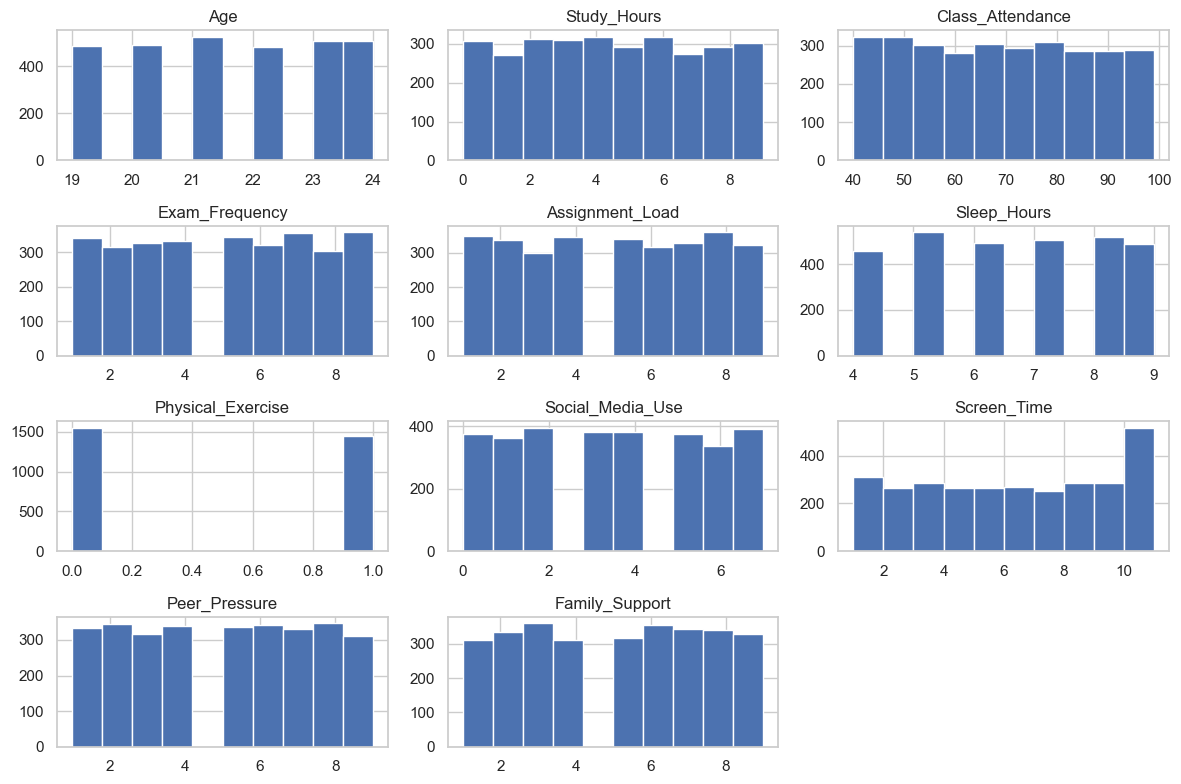

In [25]:
#CEK DISTRIBUSI NUMERIK
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20620\1946362641.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Stress_Level", data=df, order=order, palette="Set2", ax=axes[0])


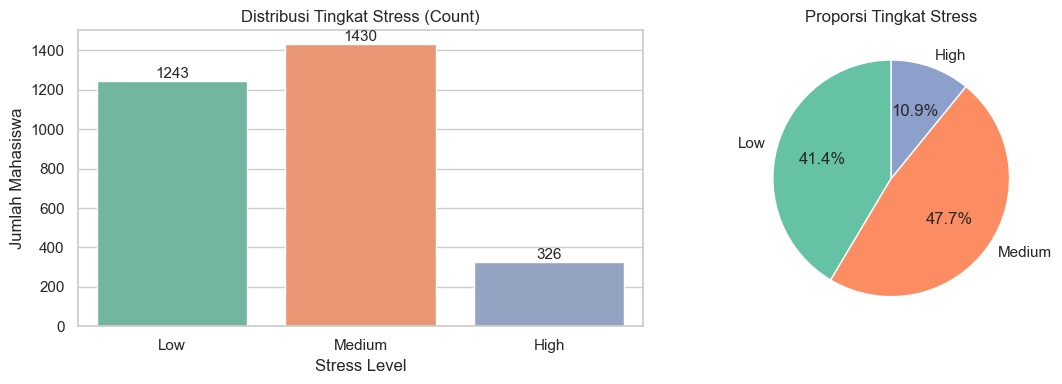

Distribusi Stress Level:
Stress_Level
Low       41.4%
Medium    47.7%
High      10.9%
Name: proportion, dtype: object


In [26]:
# order = ["Low","Medium","High"]

# sns.countplot(x="Stress_Level", data=df, order=order)
# plt.title("Distribusi Tingkat Stress")
# plt.show()

order = ["Low", "Medium", "High"]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Count plot
sns.countplot(x="Stress_Level", data=df, order=order, hue="Stress_Level", legend=False, palette="Set2", ax=axes[0])
axes[0].set_title("Distribusi Tingkat Stress (Count)")
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("Jumlah Mahasiswa")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)
 
# Pie chart
counts = df["Stress_Level"].value_counts().reindex(order)
axes[1].pie(counts, labels=order, autopct='%1.1f%%',
            colors=sns.color_palette("Set2", 3), startangle=90)
axes[1].set_title("Proporsi Tingkat Stress")
 
plt.tight_layout()
plt.show()
 
print("Distribusi Stress Level:")
print(df["Stress_Level"].value_counts(normalize=True).reindex(order).mul(100).round(1).astype(str) + "%")

## DISTRIBUSI FITUR NUMERIK

In [27]:
# plt.figure(figsize=(10,6))
# sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
# plt.title("Correlation Matrix")
# plt.show()

### KORELASI

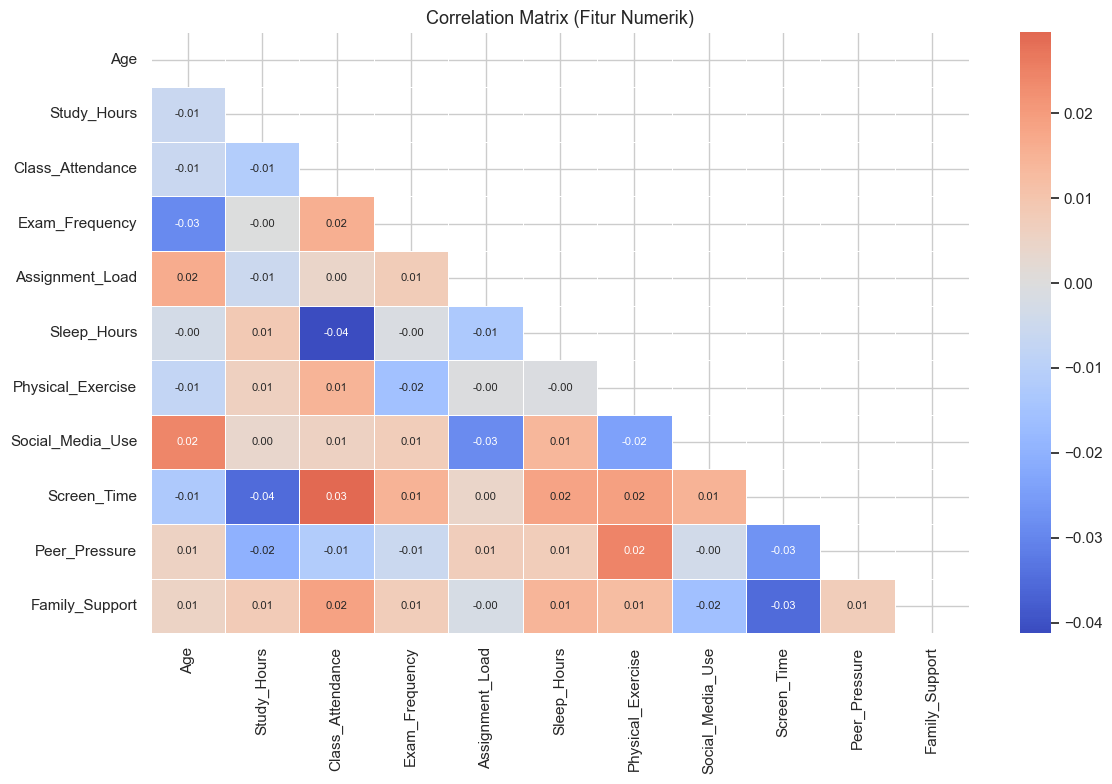

In [28]:
# corr = df.corr(numeric_only=True)["Screen_Time"].sort_values(ascending=False)
# print(corr)

plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Correlation Matrix (Fitur Numerik)", fontsize=13)
plt.tight_layout()
plt.show()

# BUSINESS QUESTIONS

### BQ1: Faktor apa yang paling berpengaruh terhadap stress?

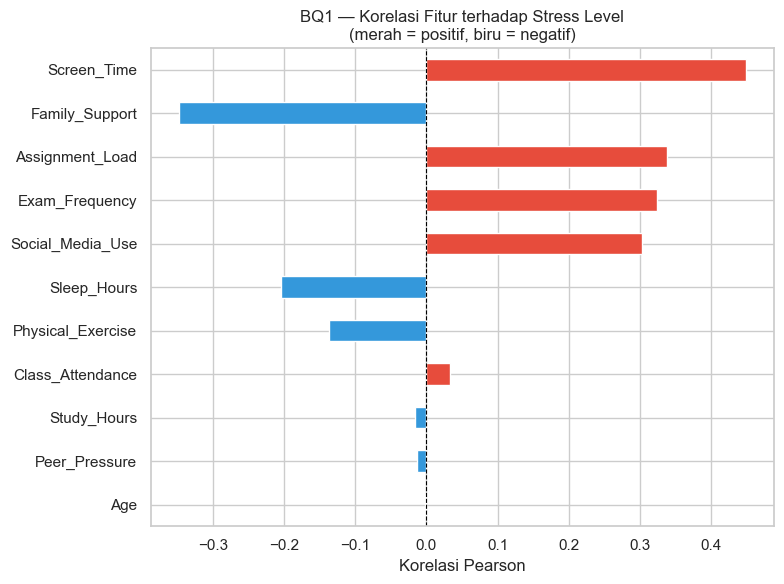


Insight BQ1:
  Faktor yang MENINGKATKAN stress: Screen_Time, Assignment_Load, Exam_Frequency
  Faktor yang MENURUNKAN stress : Family_Support, Sleep_Hours, Physical_Exercise


In [29]:
# corr = df.corr(numeric_only=True)["Sleep_Hours"].sort_values()
# print(corr)

# Encode Stress_Level menjadi numerik untuk korelasi
stress_map = {"Low": 0, "Medium": 1, "High": 2}
df["Stress_Num"] = df["Stress_Level"].map(stress_map)
 
corr_stress = (
    df.corr(numeric_only=True)["Stress_Num"]
    .drop("Stress_Num")
    .sort_values(key=abs, ascending=True)
)
 
plt.figure(figsize=(8, 6))
colors = ["#E74C3C" if v > 0 else "#3498DB" for v in corr_stress]
corr_stress.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("BQ1 — Korelasi Fitur terhadap Stress Level\n(merah = positif, biru = negatif)", fontsize=12)
plt.xlabel("Korelasi Pearson")
plt.tight_layout()
plt.show()
 
print("\nInsight BQ1:")
top_pos = corr_stress[corr_stress > 0].nlargest(3)
top_neg = corr_stress[corr_stress < 0].nsmallest(3)
print(f"  Faktor yang MENINGKATKAN stress: {', '.join(top_pos.index.tolist())}")
print(f"  Faktor yang MENURUNKAN stress : {', '.join(top_neg.index.tolist())}")
 
df.drop(columns=["Stress_Num"], inplace=True)

#### BQ2: Apakah tidur < 6 jam berhubungan dengan stress lebih tinggi?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20620\587285151.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y="Sleep_Hours", data=df, order=order,


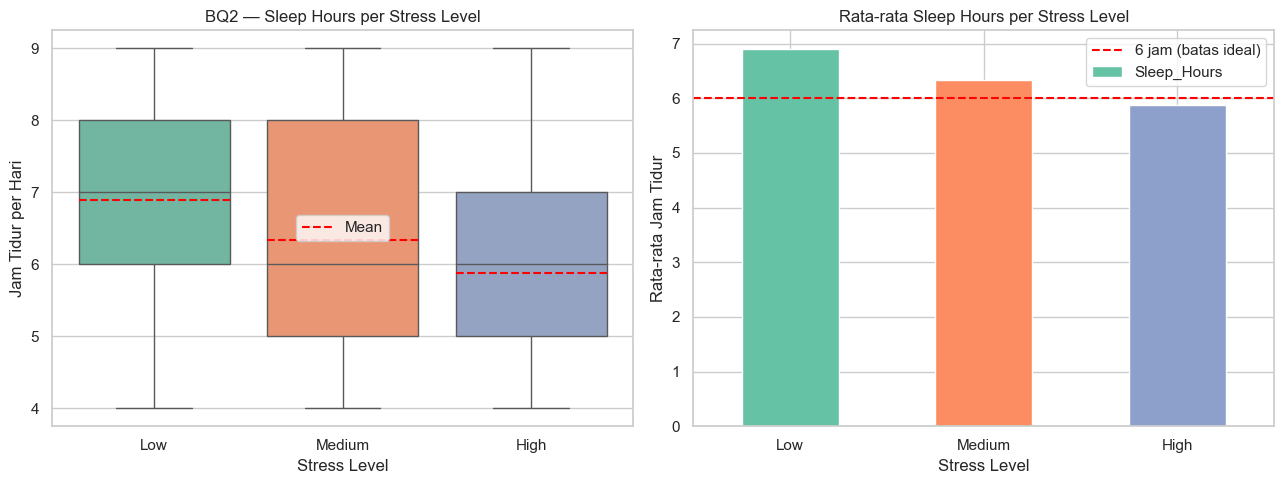


Insight BQ2:
Stress_Level
Low       6.90
Medium    6.34
High      5.88

  33.2% mahasiswa tidur kurang dari 6 jam per hari


In [30]:
# sns.boxplot(x="Stress_Level", y="Sleep_Hours", data=df, order=order)
# plt.title("Pengaruh Sleep Hours terhadap Stress")
# plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Boxplot
sns.boxplot(x="Stress_Level", y="Sleep_Hours", data=df, order=order,
            hue="Stress_Level", legend=False, palette="Set2", ax=axes[0])
group_means = df.groupby("Stress_Level")["Sleep_Hours"].mean().reindex(order)
for i, (level, mean) in enumerate(group_means.items()):
    axes[0].hlines(mean, i - 0.4, i + 0.4, colors="red",
                   linestyles="--", linewidth=1.5, label="Mean" if i == 0 else "")
axes[0].set_title("BQ2 — Sleep Hours per Stress Level")
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("Jam Tidur per Hari")
axes[0].legend()
 
# Bar rata-rata
group_means.plot(kind="bar", color=sns.color_palette("Set2", 3), ax=axes[1], edgecolor="white")
axes[1].axhline(6, color="red", linestyle="--", linewidth=1.5, label="6 jam (batas ideal)")
axes[1].set_title("Rata-rata Sleep Hours per Stress Level")
axes[1].set_xlabel("Stress Level")
axes[1].set_ylabel("Rata-rata Jam Tidur")
axes[1].set_xticklabels(order, rotation=0)
axes[1].legend()
 
plt.tight_layout()
plt.show()
 
print("\nInsight BQ2:")
print(df.groupby("Stress_Level")["Sleep_Hours"].mean().reindex(order).round(2).to_string())
low_sleep = (df["Sleep_Hours"] < 6).mean() * 100
print(f"\n  {low_sleep:.1f}% mahasiswa tidur kurang dari 6 jam per hari")

### BQ3: Apakah screen time tinggi berhubungan dengan stress lebih besar?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20620\3477405914.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y="Screen_Time", data=df, order=order,


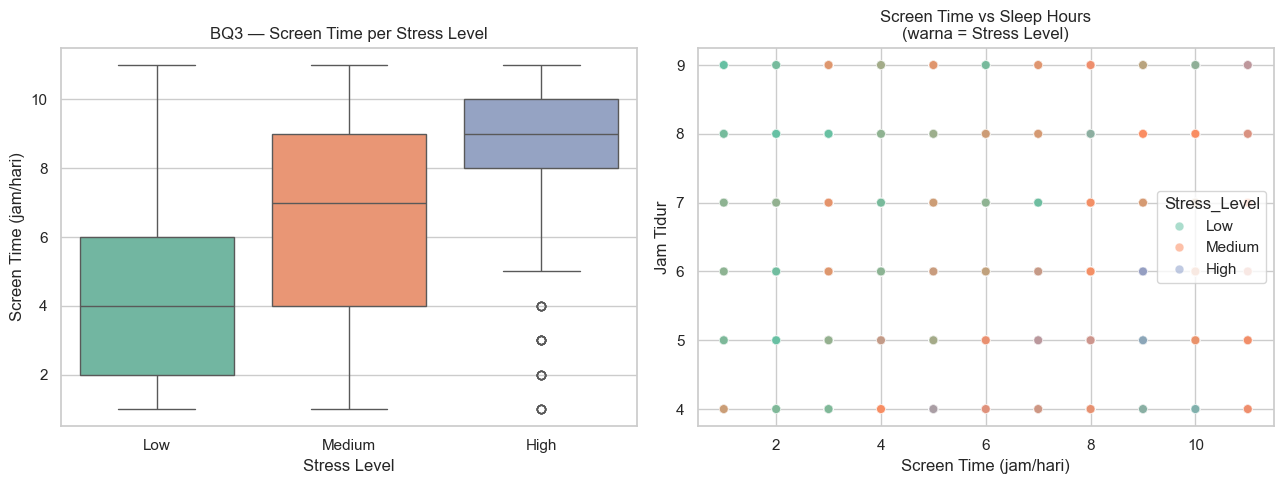


 Insight BQ3:
Stress_Level
Low       4.37
Medium    6.64
High      8.65


In [31]:
# df.groupby("Stress_Level")["Sleep_Hours"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Boxplot
sns.boxplot(x="Stress_Level", y="Screen_Time", data=df, order=order,
            palette="Set2", ax=axes[0])
axes[0].set_title("BQ3 — Screen Time per Stress Level")
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("Screen Time (jam/hari)")
 
# Scatter screen time vs sleep, hue=stress
sns.scatterplot(
    x="Screen_Time", y="Sleep_Hours", hue="Stress_Level",
    hue_order=order, data=df, palette="Set2", alpha=0.55,
    s=40, ax=axes[1]
)
axes[1].set_title("Screen Time vs Sleep Hours\n(warna = Stress Level)")
axes[1].set_xlabel("Screen Time (jam/hari)")
axes[1].set_ylabel("Jam Tidur")
 
plt.tight_layout()
plt.show()
 
print("\n Insight BQ3:")
print(df.groupby("Stress_Level")["Screen_Time"].mean().reindex(order).round(2).to_string())

### BQ4: Pengaruh Peer Pressure & Family Support terhadap stress?

## Screen Time vs Stress

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20620\1677641406.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y="Peer_Pressure", data=df, order=order,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20620\1677641406.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y="Family_Support", data=df, order=order,


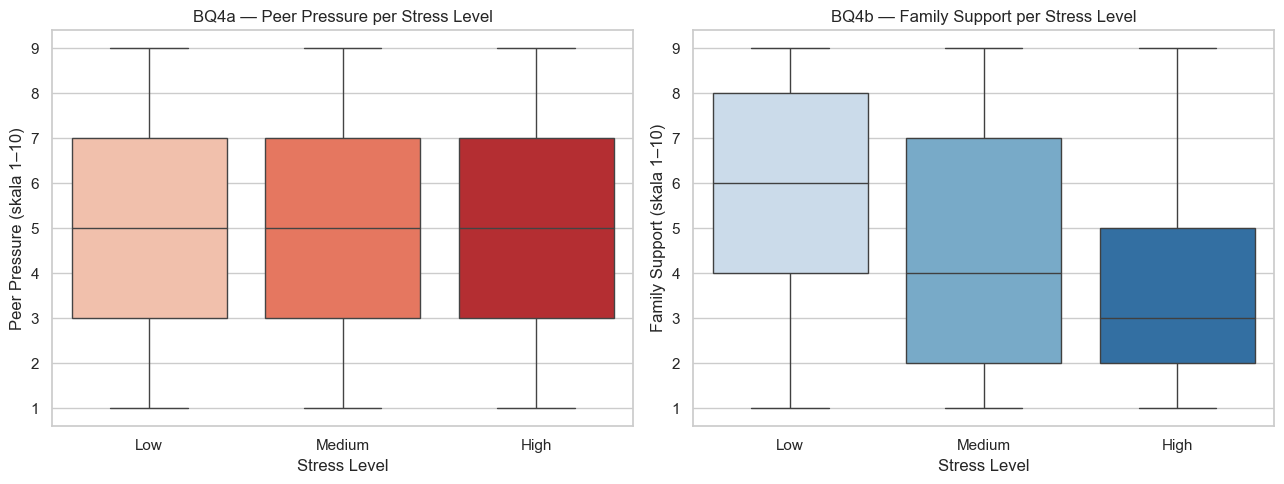


Insight BQ4:
              Peer_Pressure  Family_Support
Stress_Level                               
Low                    5.00            5.99
Medium                 5.01            4.58
High                   4.83            3.31


In [32]:
# sns.boxplot(x="Stress_Level", y="Screen_Time", data=df, order=order)
# plt.title("Pengaruh Screen Time terhadap Stress")
# plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
sns.boxplot(x="Stress_Level", y="Peer_Pressure", data=df, order=order,
            hue="Stress_Level", legend=False, palette="Reds", ax=axes[0])
axes[0].set_title("BQ4a — Peer Pressure per Stress Level")
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("Peer Pressure (skala 1–10)")
 
sns.boxplot(x="Stress_Level", y="Family_Support", data=df, order=order,
            hue="Stress_Level", legend=False, palette="Blues", ax=axes[1])
axes[1].set_title("BQ4b — Family Support per Stress Level")
axes[1].set_xlabel("Stress Level")
axes[1].set_ylabel("Family Support (skala 1–10)")
 
plt.tight_layout()
plt.show()
 
print("\nInsight BQ4:")
print(df.groupby("Stress_Level")[["Peer_Pressure", "Family_Support"]].mean().reindex(order).round(2).to_string())

### BQ5: Apakah mahasiswa yang ikut les (Tuition) lebih stres?

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20620\2951870241.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Tuition", "Stress_Level"])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20620\2951870241.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .div(df.groupby("Tuition").size(), axis=0)


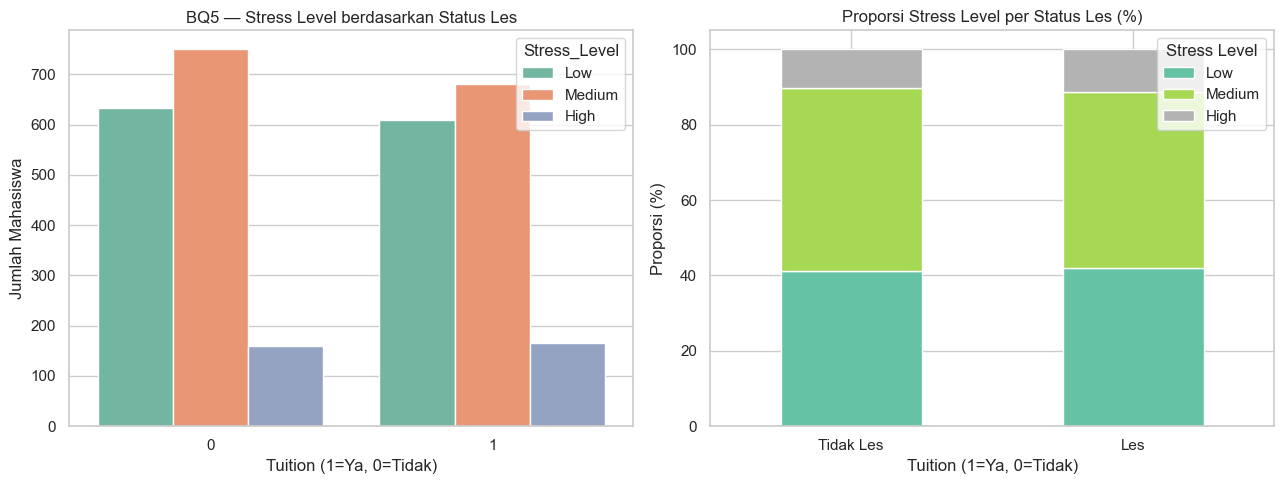


Insight BQ5:
Stress_Level   Low  Medium  High
Tuition                         
0             41.1    48.6  10.4
1             41.9    46.7  11.4


In [33]:
# sns.scatterplot(x="Screen_Time", y="Sleep_Hours", hue="Stress_Level", data=df)
# plt.title("Screen Time vs Sleep Hours")
# plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Countplot
sns.countplot(x="Tuition", hue="Stress_Level", data=df,
              hue_order=order, palette="Set2", ax=axes[0])
axes[0].set_title("BQ5 — Stress Level berdasarkan Status Les")
axes[0].set_xlabel("Tuition (1=Ya, 0=Tidak)")
axes[0].set_ylabel("Jumlah Mahasiswa")
 
# Stacked bar proporsi
tuition_stress = (
    df.groupby(["Tuition", "Stress_Level"])
    .size()
    .unstack("Stress_Level")
    .reindex(columns=order)
    .div(df.groupby("Tuition").size(), axis=0)
    * 100
)
tuition_stress.plot(
    kind="bar", stacked=True, colormap="Set2", ax=axes[1], edgecolor="white"
)
axes[1].set_title("Proporsi Stress Level per Status Les (%)")
axes[1].set_xlabel("Tuition (1=Ya, 0=Tidak)")
axes[1].set_ylabel("Proporsi (%)")
axes[1].set_xticklabels(["Tidak Les", "Les"], rotation=0)
axes[1].legend(title="Stress Level", loc="upper right")
 
plt.tight_layout()
plt.show()
 
print("\nInsight BQ5:")
print(tuition_stress.round(1).to_string())
 

### BQ6 — Study Hours vs Stress

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20620\3545779729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y="Study_Hours", data=df, order=order,


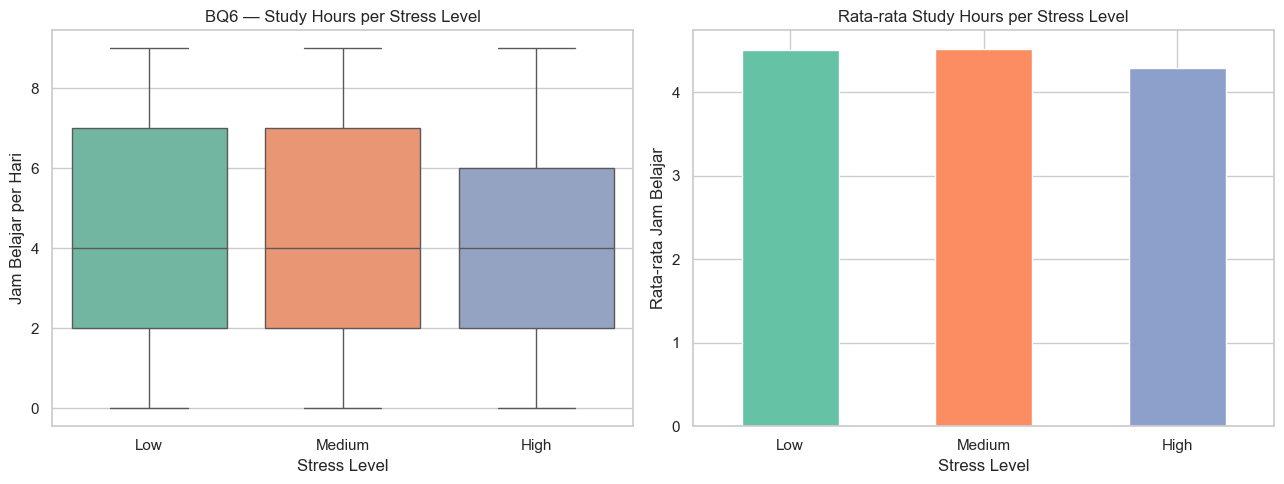


Insight BQ6:
Stress_Level
Low       4.51
Medium    4.51
High      4.29


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x="Stress_Level", y="Study_Hours", data=df, order=order,
            hue="Stress_Level", legend=False, palette="Set2", ax=axes[0])
axes[0].set_title("BQ6 — Study Hours per Stress Level")
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("Jam Belajar per Hari")

group_means = df.groupby("Stress_Level")["Study_Hours"].mean().reindex(order)
group_means.plot(kind="bar", color=sns.color_palette("Set2", 3),
                 ax=axes[1], edgecolor="white")
axes[1].set_title("Rata-rata Study Hours per Stress Level")
axes[1].set_xlabel("Stress Level")
axes[1].set_ylabel("Rata-rata Jam Belajar")
axes[1].set_xticklabels(order, rotation=0)

plt.tight_layout()
plt.show()

print("\nInsight BQ6:")
print(df.groupby("Stress_Level")["Study_Hours"].mean().reindex(order).round(2).to_string())

### BQ7 — Gender vs Stress

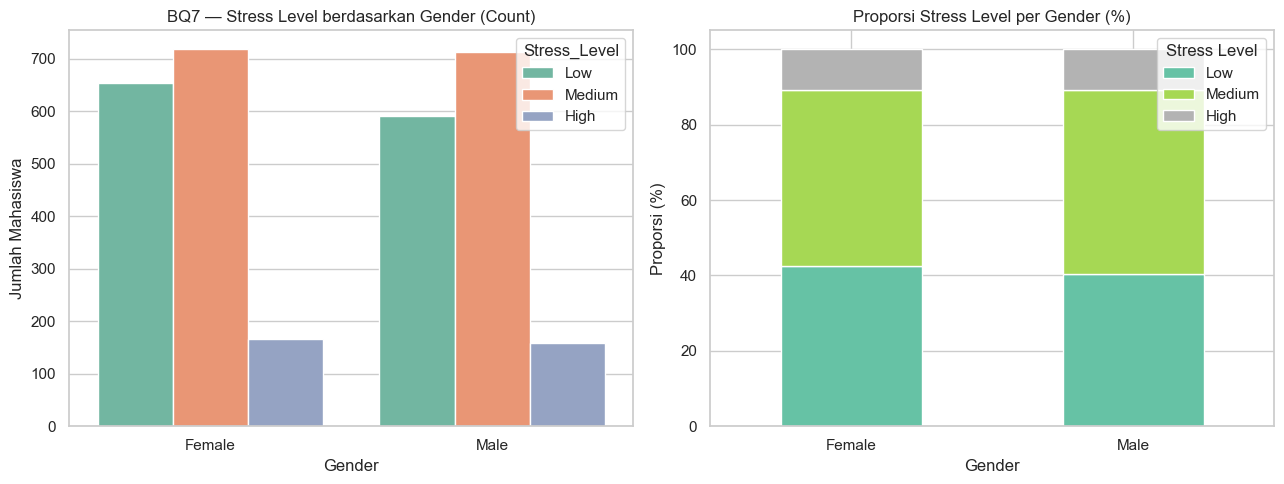


Insight BQ7:
Stress_Level   Low  Medium  High
Gender                          
Female        42.5    46.7  10.9
Male          40.4    48.7  10.9


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x="Gender", hue="Stress_Level", data=df,
              hue_order=order, palette="Set2", ax=axes[0])
axes[0].set_title("BQ7 — Stress Level berdasarkan Gender (Count)")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Jumlah Mahasiswa")

gender_stress = (
    df.groupby(["Gender", "Stress_Level"])
    .size()
    .unstack("Stress_Level")
    .reindex(columns=order)
    .div(df.groupby("Gender").size(), axis=0)
    * 100
)
gender_stress.plot(kind="bar", stacked=True, colormap="Set2",
                   ax=axes[1], edgecolor="white")
axes[1].set_title("Proporsi Stress Level per Gender (%)")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Proporsi (%)")
axes[1].set_xticklabels(gender_stress.index, rotation=0)
axes[1].legend(title="Stress Level", loc="upper right")

plt.tight_layout()
plt.show()

print("\nInsight BQ7:")
print(gender_stress.round(1).to_string())

###  RINGKASAN INSIGHT EDA
1. BQ1 — Faktor dominan stress:
    - (korelasi positif) Screen time, Exam frequency, Assignment load 
    - (korelasi negatif) Sleep hours, Family support, Physical exercise 
2. BQ2 — Sleep & Stress:
    - Low stress tidur 6.90 jam, High stress hanya 5.88 jam
    - 33.2% mahasiswa tidur kurang dari 6 jam per hari 
3. BQ3 — Screen Time & Stress:
    - Low=4.37 jam, Medium=6.64 jam, High=8.65 jam/hari 
    - Semakin tinggi stress, screen time naik drastis
4. BQ4 — Peer Pressure & Family Support: 
    - Family support turun tajam: Low=5.99, Med=4.58, High=3.31
    - Peer pressure relatif stabil di semua kategori (~5.0)
5. BQ5 — Tuition & Stress:
    - Mahasiswa les sedikit lebih banyak di High stress
    - (11.4% vs 10.4%) — perbedaan tidak terlalu signifikan 
6. BQ6 — Study Hours & Stress:
    - Jam belajar hampir sama di semua kategori (~4.5 jam)
    - Study hours TIDAK berpengaruh signifikan terhadap stress 
7. BQ7 — Gender & Stress: 
    - Proporsi High stress sama antara pria & wanita (10.9%)
    - Gender TIDAK menunjukkan perbedaan pola stress

In [36]:
# sns.boxplot(x="Stress_Level", y="Study_Hours", data=df, order=order)
# plt.title("Pengaruh Study Hours terhadap Stress")
# plt.show()

In [37]:
# sns.countplot(x="Gender", hue="Stress_Level", data=df, hue_order=order)
# plt.title("Stress berdasarkan Gender")
# plt.show()

## Tuition vs Stress 

In [38]:
# sns.countplot(x="Tuition", hue="Stress_Level", data=df, hue_order=order)
# plt.title("Pengaruh Private Coaching terhadap Stress")
# plt.show()

In [39]:
# sns.boxplot(x="Stress_Level", y="Peer_Pressure", data=df, order=order)
# plt.title("Peer Pressure vs Stress")
# plt.show()

In [40]:
#df["Stress_Level"].value_counts(normalize=True)*100

# 6. FEATURE ENGINEERING

In [41]:
df["Sleep_Deficit"] = (7 - df["Sleep_Hours"]).clip(lower=0)

df["Screen_to_Sleep"] = df["Screen_Time"] / (df["Sleep_Hours"] + 1)

df.head()

,Age,Gender,Study_Hours,Class_Attendance,Tuition,Exam_Frequency,Assignment_Load,Sleep_Hours,Physical_Exercise,Social_Media_Use,Screen_Time,Family_Income_Level,Peer_Pressure,Family_Support,University_Type,Stress_Level,Sleep_Deficit,Screen_to_Sleep
0,24,Female,8,43,1,6,8,5,1,6,8,Medium,3,7,National University,High,2,1.333333
1,21,Female,4,56,1,3,6,5,1,7,9,Low,2,5,Private University,Medium,2,1.500000
2,23,Female,4,46,0,8,6,8,0,5,6,Medium,8,6,Private University,Medium,0,0.666667
3,20,Male,8,46,0,5,1,6,1,0,7,Medium,5,6,National University,Low,1,1.000000
4,19,Male,2,95,0,5,2,7,0,3,6,Low,2,6,National University,Low,0,0.750000


In [42]:
(df.select_dtypes(include="number") < 0).sum()

Age                  0
Study_Hours          0
Class_Attendance     0
Exam_Frequency       0
Assignment_Load      0
Sleep_Hours          0
Physical_Exercise    0
Social_Media_Use     0
Screen_Time          0
Peer_Pressure        0
Family_Support       0
Sleep_Deficit        0
Screen_to_Sleep      0
dtype: int64

In [43]:
# Productivity vs distraction
df["Study_to_Screen"] = df["Study_Hours"] / (df["Screen_Time"] + 1)

# Pressure vs support
df["Pressure_Index"] = (df["Peer_Pressure"] + 1) / (df["Family_Support"] + 1)

# Lifestyle balance
df["Activity_Balance"] = df["Physical_Exercise"] / (df["Screen_Time"] + 1)

In [44]:
df["Lifestyle_Risk"] = (
    df["Screen_Time"] +
    df["Peer_Pressure"] -
    df["Sleep_Hours"] -
    df["Physical_Exercise"]
)

# Geser nilai negatif agar nilai minimum menjadi 0
min_risk = df["Lifestyle_Risk"].min()
if min_risk < 0:
    df["Lifestyle_Risk"] = df["Lifestyle_Risk"] + abs(min_risk)


In [45]:
df["Academic_Pressure"] = (
    df["Assignment_Load"] +
    df["Exam_Frequency"] +
    df["Study_Hours"]
)

In [46]:
df["Rest_Efficiency"] = df["Sleep_Hours"] / (df["Screen_Time"] + 1)

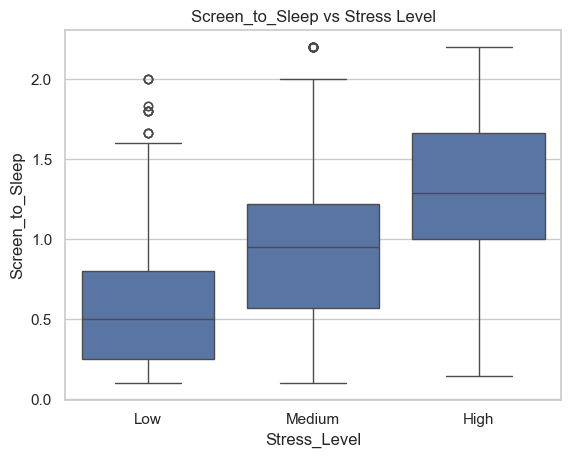

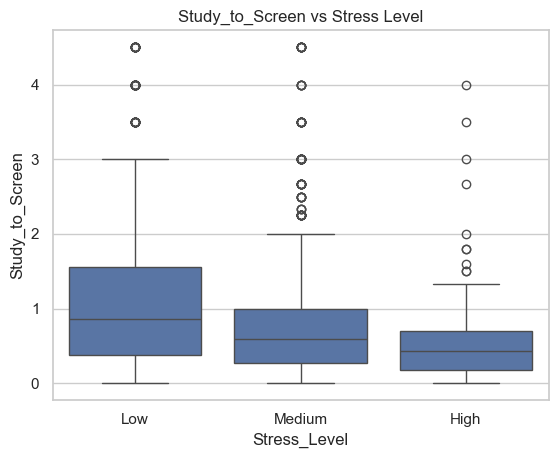

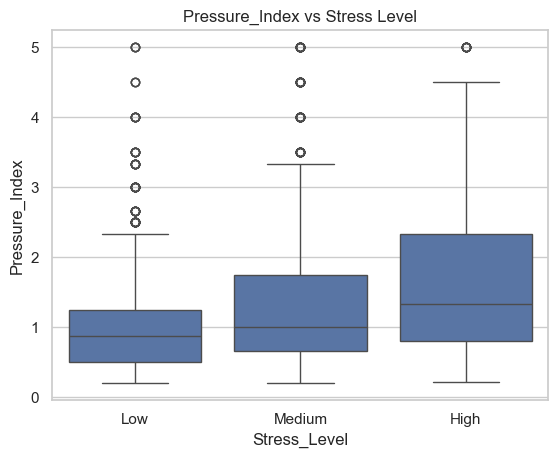

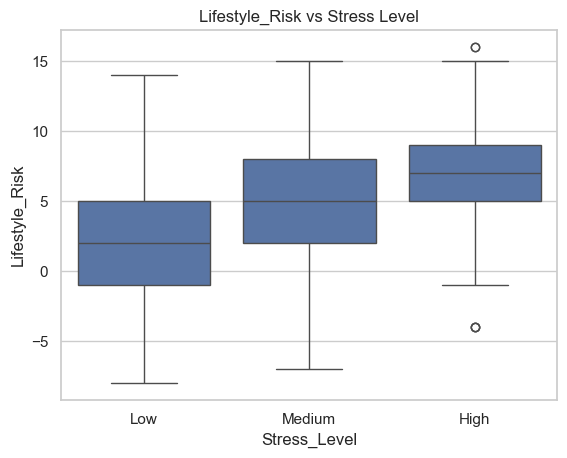

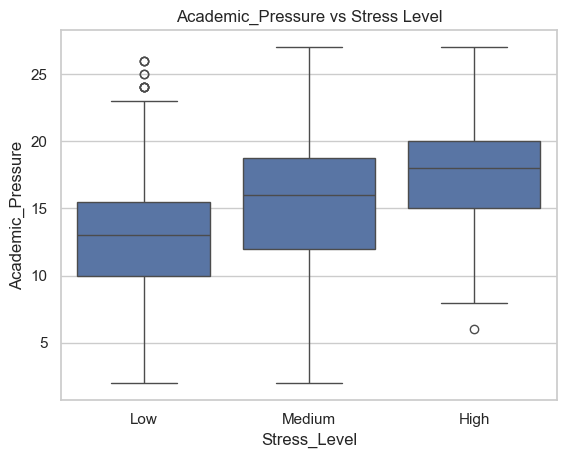

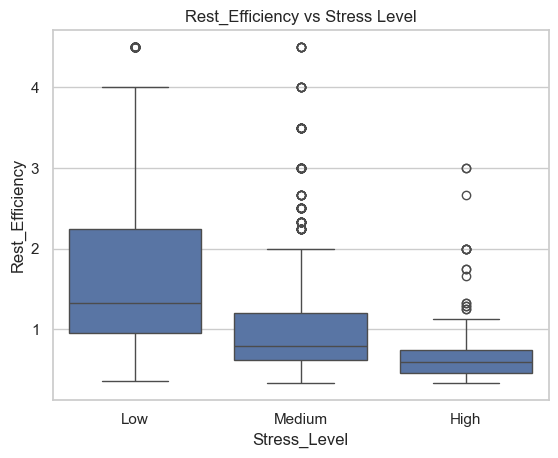

In [47]:
order = ["Low", "Medium", "High"]

new_features = [
    "Screen_to_Sleep",
    "Study_to_Screen",
    "Pressure_Index",
    "Lifestyle_Risk",
    "Academic_Pressure",
    "Rest_Efficiency"
]

for col in new_features:
    sns.boxplot(x="Stress_Level", y=col, data=df, order=order)
    plt.title(f"{col} vs Stress Level")
    plt.show()

In [48]:
print("Check negative:")
print((df.select_dtypes(include="number") < 0).sum())

import numpy as np
print("\nCheck infinity:")
print(np.isinf(df.select_dtypes(include="number")).sum())

print("\nCheck NaN:")
print(df.isnull().sum())

Check negative:
Age                    0
Study_Hours            0
Class_Attendance       0
Exam_Frequency         0
Assignment_Load        0
Sleep_Hours            0
Physical_Exercise      0
Social_Media_Use       0
Screen_Time            0
Peer_Pressure          0
Family_Support         0
Sleep_Deficit          0
Screen_to_Sleep        0
Study_to_Screen        0
Pressure_Index         0
Activity_Balance       0
Lifestyle_Risk       519
Academic_Pressure      0
Rest_Efficiency        0
dtype: int64

Check infinity:
Age                  0
Study_Hours          0
Class_Attendance     0
Exam_Frequency       0
Assignment_Load      0
Sleep_Hours          0
Physical_Exercise    0
Social_Media_Use     0
Screen_Time          0
Peer_Pressure        0
Family_Support       0
Sleep_Deficit        0
Screen_to_Sleep      0
Study_to_Screen      0
Pressure_Index       0
Activity_Balance     0
Lifestyle_Risk       0
Academic_Pressure    0
Rest_Efficiency      0
dtype: int64

Check NaN:
Age              

In [49]:
new_features = [
    "Sleep_Deficit",
    "Screen_to_Sleep",
    "Study_to_Screen",
    "Pressure_Index",
    "Lifestyle_Risk",
    "Academic_Pressure",
    "Rest_Efficiency",
    "Activity_Balance"
]

In [50]:
print(df.dtypes)

Age                       int64
Gender                   object
Study_Hours               int64
Class_Attendance          int64
Tuition                category
Exam_Frequency            int64
Assignment_Load           int64
Sleep_Hours               int64
Physical_Exercise         int64
Social_Media_Use          int64
Screen_Time               int64
Family_Income_Level    category
Peer_Pressure             int64
Family_Support            int64
University_Type          object
Stress_Level             object
Sleep_Deficit             int64
Screen_to_Sleep         float64
Study_to_Screen         float64
Pressure_Index          float64
Activity_Balance        float64
Lifestyle_Risk            int64
Academic_Pressure         int64
Rest_Efficiency         float64
dtype: object


In [51]:
df.groupby("Stress_Level")[[
    "Sleep_Hours",
    "Screen_Time",
    "Study_Hours"
]].mean().round(2)

,Sleep_Hours,Screen_Time,Study_Hours
Stress_Level,,,
High,5.88,8.65,4.29
Low,6.90,4.37,4.51
Medium,6.34,6.64,4.51


In [52]:
print("Check NaN:\n", df.isnull().sum())
print("\nCheck negative:\n", (df.select_dtypes(include="number") < 0).sum())

import numpy as np
print("\nCheck infinity:\n", np.isinf(df.select_dtypes(include="number")).sum())

Check NaN:
 Age                    0
Gender                 0
Study_Hours            0
Class_Attendance       0
Tuition                0
Exam_Frequency         0
Assignment_Load        0
Sleep_Hours            0
Physical_Exercise      0
Social_Media_Use       0
Screen_Time            0
Family_Income_Level    0
Peer_Pressure          0
Family_Support         0
University_Type        0
Stress_Level           0
Sleep_Deficit          0
Screen_to_Sleep        0
Study_to_Screen        0
Pressure_Index         0
Activity_Balance       0
Lifestyle_Risk         0
Academic_Pressure      0
Rest_Efficiency        0
dtype: int64

Check negative:
 Age                    0
Study_Hours            0
Class_Attendance       0
Exam_Frequency         0
Assignment_Load        0
Sleep_Hours            0
Physical_Exercise      0
Social_Media_Use       0
Screen_Time            0
Peer_Pressure          0
Family_Support         0
Sleep_Deficit          0
Screen_to_Sleep        0
Study_to_Screen        0
Pressur

In [53]:
df[new_features].head()

,Sleep_Deficit,Screen_to_Sleep,Study_to_Screen,Pressure_Index,Lifestyle_Risk,Academic_Pressure,Rest_Efficiency,Activity_Balance
0,2,1.333333,0.888889,0.500000,5,22,0.555556,0.111111
1,2,1.500000,0.400000,0.500000,5,13,0.500000,0.100000
2,0,0.666667,0.571429,1.285714,6,18,1.142857,0.000000
3,1,1.000000,1.000000,0.857143,5,14,0.750000,0.125000
4,0,0.750000,0.285714,0.428571,1,9,1.000000,0.000000


# 7. PREPROCESSING

## Split

In [54]:
from sklearn.model_selection import train_test_split

# Drop feature yang kurang relevan berdasarkan EDA
df = df.drop(columns=["Study_Hours", "Gender"], errors="ignore")

X = df.drop(columns=["Stress_Level"])
# Ubah target string menjadi numerik (0, 1, 2)
stress_map = {"Low": 0, "Medium": 1, "High": 2}
y = df["Stress_Level"].map(stress_map)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Encoding + Column Setup

In [55]:
num_cols = df.drop(columns=["Stress_Level"]).select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_cols = df.drop(columns=["Stress_Level"]).select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['Age', 'Study_Hours', 'Class_Attendance', 'Exam_Frequency', 'Assignment_Load', 'Sleep_Hours', 'Physical_Exercise', 'Social_Media_Use', 'Screen_Time', 'Peer_Pressure', 'Family_Support', 'Sleep_Deficit', 'Screen_to_Sleep', 'Study_to_Screen', 'Pressure_Index', 'Activity_Balance', 'Lifestyle_Risk', 'Academic_Pressure', 'Rest_Efficiency']
Categorical: ['Gender', 'Tuition', 'Family_Income_Level', 'University_Type']


## Scaling + Encoding (ColumnTransformer)

In [56]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

## Pipeline

In [57]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

## Transform

In [58]:
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Penanganan Class Imbalance dengan SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_processed, y_train = smote.fit_resample(X_train_processed, y_train)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)


Train shape: (2399, 29)
Test shape: (600, 29)


In [59]:
feature_names = preprocessor.get_feature_names_out()
print("Total features:", len(feature_names))

Total features: 29


## Save Artifact

In [60]:
import joblib

joblib.dump(pipeline, "preprocessing_pipeline.pkl")

['preprocessing_pipeline.pkl']

In [61]:
np.save("X_train.npy", X_train_processed)
np.save("X_test.npy", X_test_processed)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# 8. MODELING (Anak AI)

# 9. EVALUATION (Anak AI)